In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
#from analysis import *
import glob
import re
import hvplot.xarray
import matplotlib as mpl
from scipy.optimize import curve_fit
def lin(x, m, c):
    return m*x + c

In [2]:
def plot_fig_single(file_path, raw_data_label = "raw data", linear_corrected_label = "linear background corrected", sweep_field_range = [0, 10]):
    # file path format: r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-04\RTOOP_107.017_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-04_1.csv'
    # raw data label should be a string
    data_df = pd.read_csv(file_path,comment='#')
    popt, pcov = curve_fit(lin,data_df.sweep_field[sweep_field_range[0]:sweep_field_range[1]], data_df.ThetaK[sweep_field_range[0]:sweep_field_range[1]])
    data_df.ThetaKavg = data_df.ThetaK - (data_df.sweep_field*popt[0] + popt[1])

    plt.figure(dpi=100)
    plt.plot(data_df.sweep_field,data_df.ThetaK*1e3, label = raw_data_label)
    plt.plot(data_df.sweep_field,data_df.ThetaKavg*1e3,label = 'Linear Background Corrected')
    #plt.title('Raw Data')
    plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
    plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
    plt.legend()
    plt.figure(dpi=100)
    plt.plot(data_df.sweep_field,data_df.ThetaKavg*1e3,label = linear_corrected_label)
    #plt.title('Raw Data')
    plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
    plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
    plt.legend()

In [3]:
# def plot_fig_stack(file_list, raw_data_label_list = [], linear_corrected_label_list=[], plot_raw=True, plot_lin_background_correct=True):
#     plt.figure(dpi=100)
#     for i in range(len(file_list)):
#         df = pd.read_csv(file_list[i],comment='#')
#         popt, pcov = curve_fit(lin,df.sweep_field[:10], df.ThetaK[:10])
#         df.ThetaKavg = df.ThetaK - (df.sweep_field*popt[0] + popt[1])
#         if len(raw_data_label_list) == len(file_list):
#             raw_data_label = raw_data_label_list[i]
#         else: 
#             raw_data_label = "Raw data"
#         if len(linear_corrected_label_list) == len(file_list):
#             linear_corrected_label = linear_corrected_label_list[i]
#         else: 
#             linear_corrected_label = "Linearly corrected data" 

#         plt.plot(df.sweep_field,df.ThetaK*1e3, label = raw_data_label)
#         plt.plot(df.sweep_field,df.ThetaKavg*1e3,label = linear_corrected_label)
        
#     plt.legend(loc=(1.04, 0))
#     plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
#     plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
#     plt.show()

In [4]:
def plot_fig_stack(file_list, raw_data_label_list = [], linear_corrected_label_list=[], plot_raw=True, plot_lin_background_correct=True):
    plt.figure(dpi=100)

    for i in range(len(file_list)):
        df = pd.read_csv(file_list[i],comment='#')
        popt, pcov = curve_fit(lin,df.sweep_field[0:10], df.ThetaK[0:10])
        df.ThetaKavg = df.ThetaK - (df.sweep_field*popt[0] + popt[1])
        df_shift = df.ThetaK[df.sweep_field == 0].values[0]
        df.ThetaK_shifted = df.ThetaK - df_shift
        df_avg_shift = df.ThetaKavg[df.sweep_field == 0].values[0]
        df.ThetaKavg_shifted = df.ThetaKavg - df_avg_shift
        if len(raw_data_label_list) == len(file_list):
            raw_data_label = raw_data_label_list[i]
        else: 
            raw_data_label = "Raw data"
        if len(linear_corrected_label_list) == len(file_list):
            linear_corrected_label = linear_corrected_label_list[i]
        else: 
            linear_corrected_label = "Linearly corrected data" 
        plt.plot(df.sweep_field,df.ThetaK_shifted*1e3, label = raw_data_label)
        plt.plot(df.sweep_field,df.ThetaKavg_shifted*1e3,label = linear_corrected_label)
        # plt.plot(df.sweep_field,df.ThetaK*1e3, label = raw_data_label)
        # plt.plot(df.sweep_field,df.ThetaKavg*1e3,label = linear_corrected_label)
        
    plt.legend(loc=(1.04, 0))
    plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
    plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
    plt.show()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaKavg = df.ThetaK - (df.sweep_field*popt[0] + popt[1])
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaK_shifted = df.ThetaK - df_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:11: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaKavg_shifted = df.ThetaKavg - df_avg_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribut

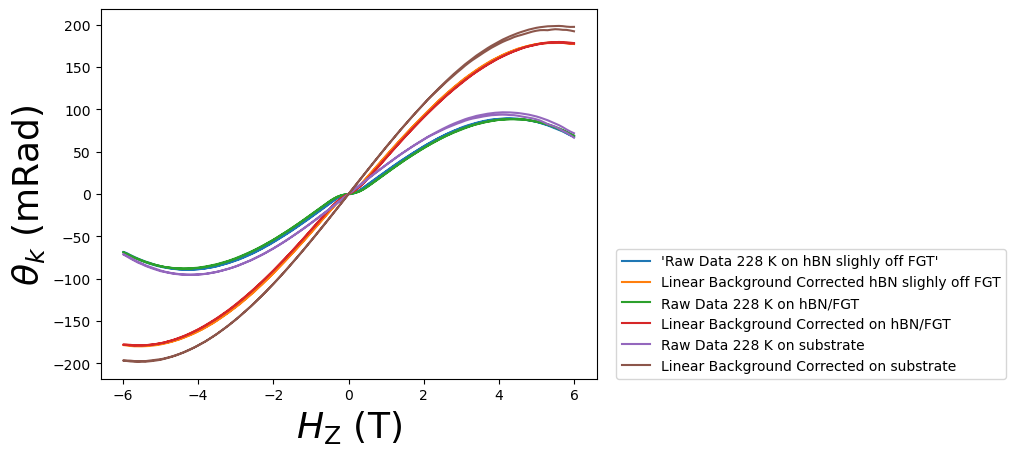

In [5]:
# example on how to use the plot_fig_stack function: 
# note it plots both 
oop1 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_6 T_hBNonly_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
oop2 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_6 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv'
oop3 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_6 T_substrate_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
test_list = [oop1, oop2, oop3]
list_raw_label = ["'Raw Data 228 K on hBN slighly off FGT'", "Raw Data 228 K on hBN/FGT", 'Raw Data 228 K on substrate']
lin_background_corrected = ["Linear Background Corrected hBN slighly off FGT", "Linear Background Corrected on hBN/FGT", 'Linear Background Corrected on substrate']
plot_fig_stack(test_list, list_raw_label, lin_background_corrected)

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\924294176.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_df.ThetaKavg = data_df.ThetaK - (data_df.sweep_field*popt[0] + popt[1])


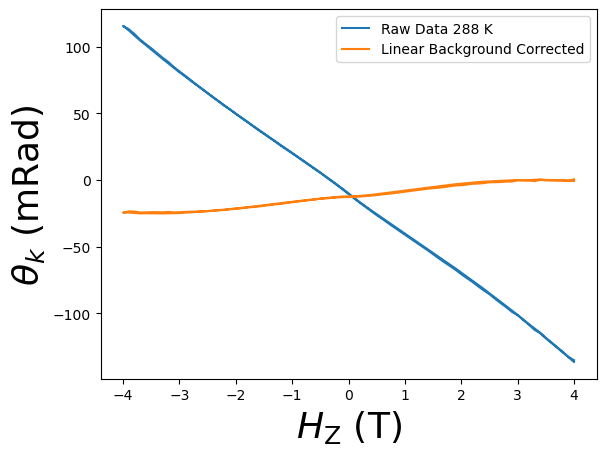

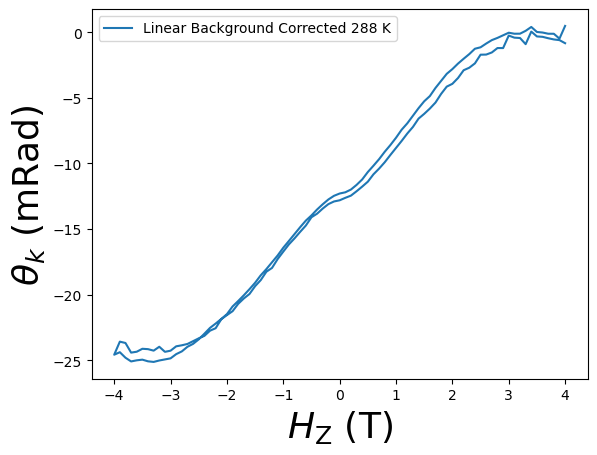

In [6]:
test_file = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-04\RTOOP_107.017_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-04_1.csv'
plot_fig_single(test_file, "Raw Data 288 K", "Linear Background Corrected 288 K")

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\924294176.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_df.ThetaKavg = data_df.ThetaK - (data_df.sweep_field*popt[0] + popt[1])


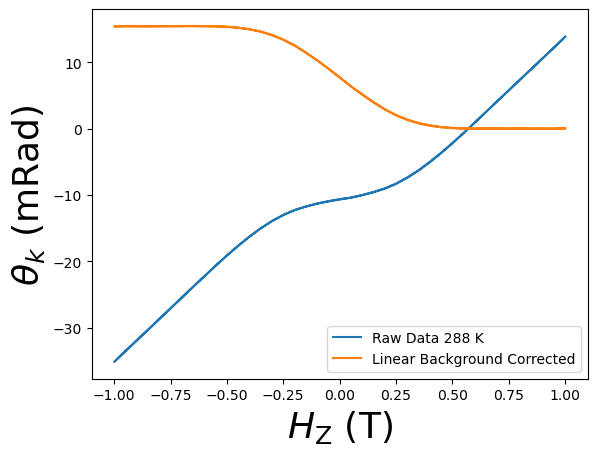

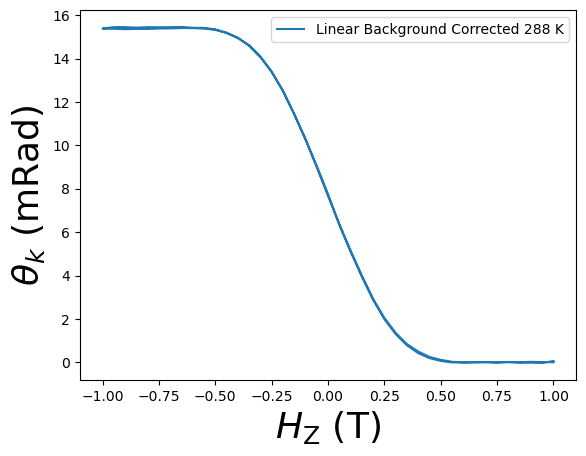

In [7]:
OOP = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_1 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv'
plot_fig_single(OOP, "Raw Data 288 K", "Linear Background Corrected 288 K")

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\2018761405.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP4.ThetaKavg = OOP4.ThetaK - (OOP4.sweep_field*popt[0] + popt[1])


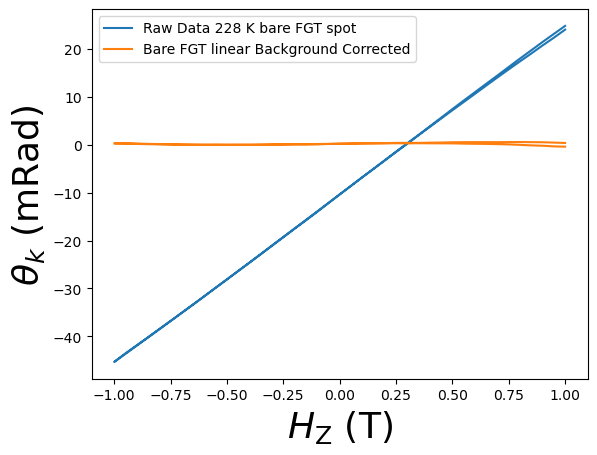

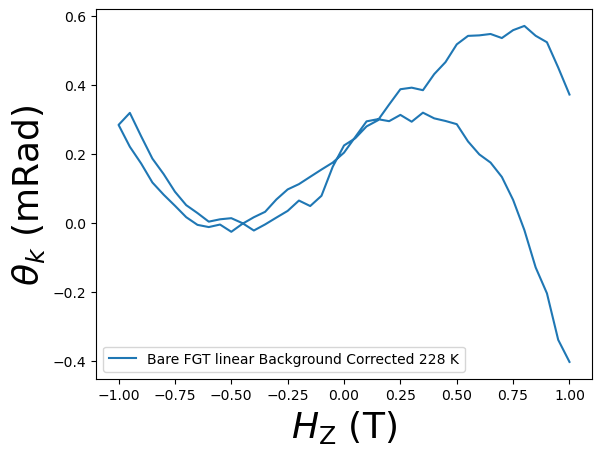

In [8]:
OOP4 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_1T_bareFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP4.sweep_field[50:55], OOP4.ThetaK[50:55])
OOP4.ThetaKavg = OOP4.ThetaK - (OOP4.sweep_field*popt[0] + popt[1])

plt.figure(dpi=100)
plt.plot(OOP4.sweep_field,OOP4.ThetaK*1e3, label = 'Raw Data 228 K bare FGT spot')
plt.plot(OOP4.sweep_field,OOP4.ThetaKavg*1e3,label = 'Bare FGT linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP4.sweep_field,OOP4.ThetaKavg*1e3,label = 'Bare FGT linear Background Corrected 228 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\924294176.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_df.ThetaKavg = data_df.ThetaK - (data_df.sweep_field*popt[0] + popt[1])


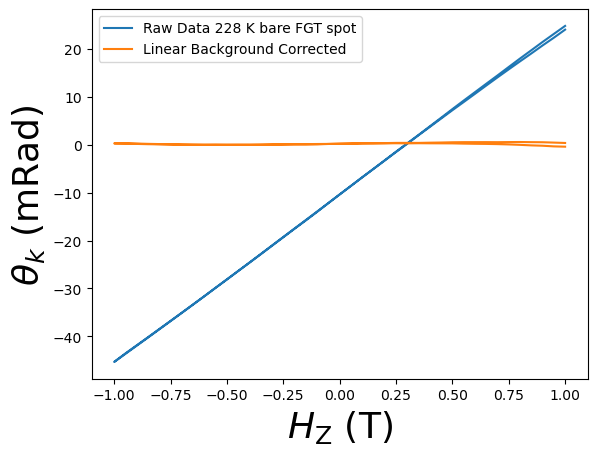

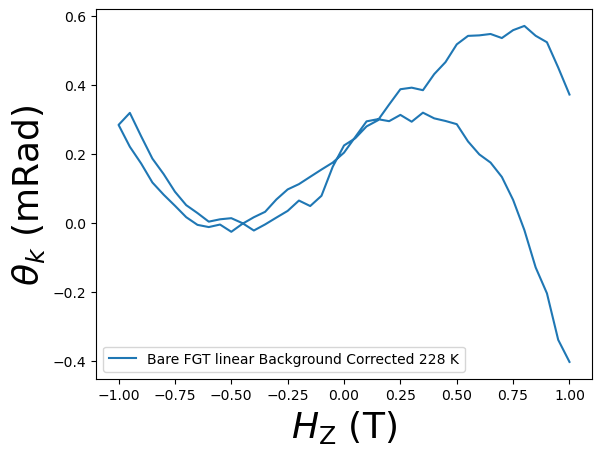

In [9]:
OOP4 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_1T_bareFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
plot_fig_single(OOP4, "Raw Data 228 K bare FGT spot", "Bare FGT linear Background Corrected 228 K", [50, 55])

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\924294176.py:6: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data_df.ThetaKavg = data_df.ThetaK - (data_df.sweep_field*popt[0] + popt[1])


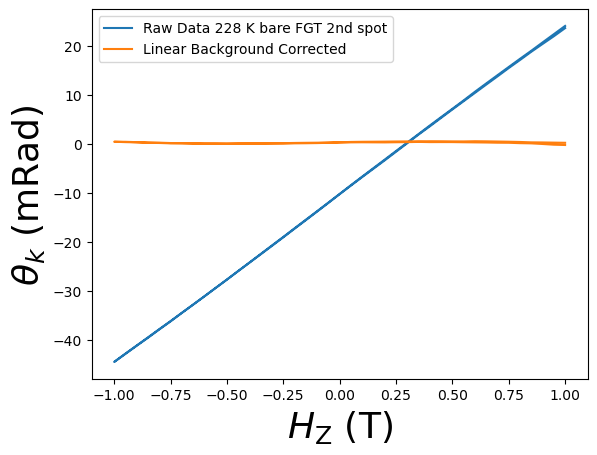

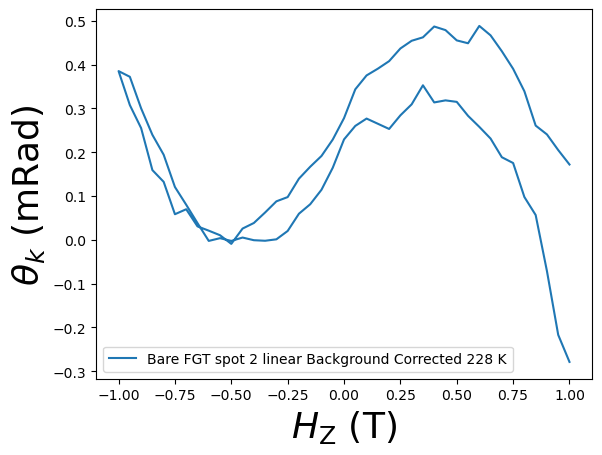

In [10]:
OOP5 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_1T_bareFGT_2ndspot_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
plot_fig_single(OOP5, "Raw Data 228 K bare FGT 2nd spot", "Bare FGT spot 2 linear Background Corrected 228 K", [50, 55])

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaKavg = df.ThetaK - (df.sweep_field*popt[0] + popt[1])
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaK_shifted = df.ThetaK - df_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:11: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.ThetaKavg_shifted = df.ThetaKavg - df_avg_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\3652654502.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribut

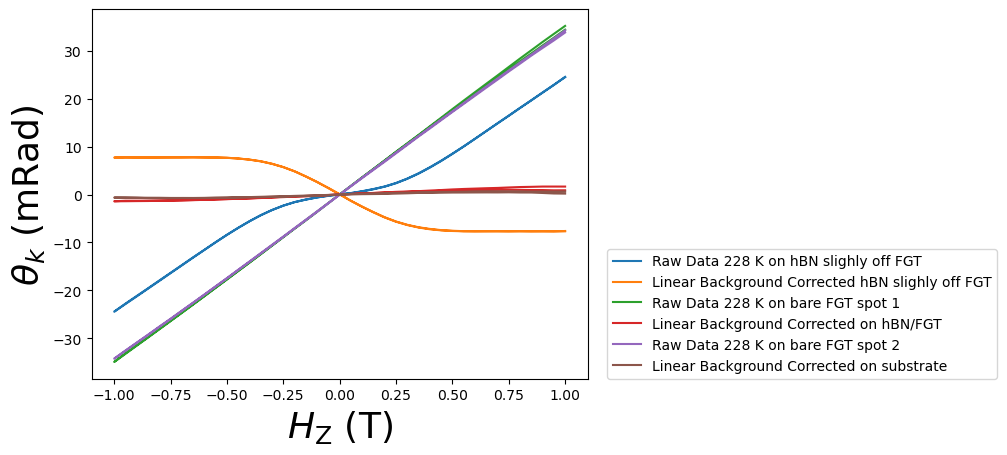

In [11]:
# example on how to use the plot_fig_stack function: 
# note it plots both 
OOP1 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_1 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv'
OOP4 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_1T_bareFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
OOP5 = r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-07\OOP_107.017_tc1s_228K_1T_bareFGT_2ndspot_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-07_1.csv'
test_list = [OOP1, OOP4, OOP5]
list_raw_label = ["Raw Data 228 K on hBN slighly off FGT", 'Raw Data 228 K on bare FGT spot 1', 'Raw Data 228 K on bare FGT spot 2']
# lin_background_corrected = ["Linear Background Corrected hBN slighly off FGT", "Linear Background Corrected on hBN/FGT", 'Linear Background Corrected on substrate']
plot_fig_stack(test_list, list_raw_label, lin_background_corrected, plot_lin_background_correct=False)

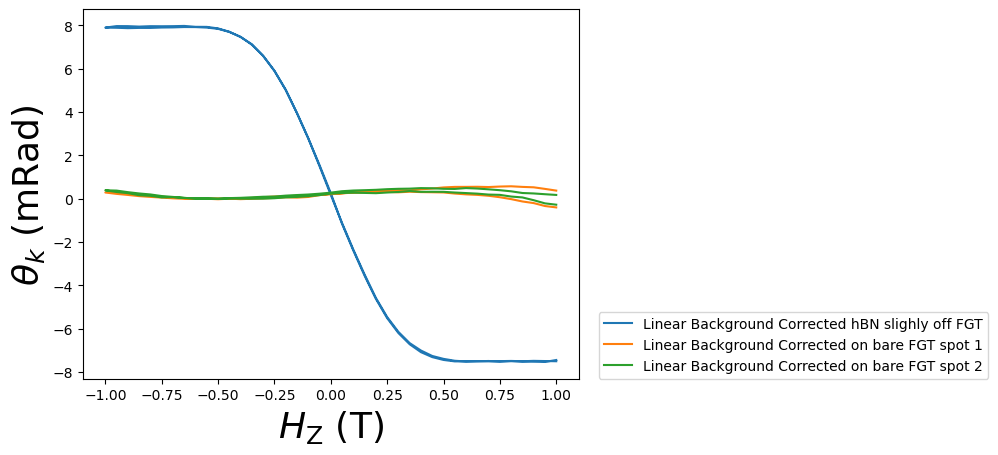

In [43]:
plt.figure(dpi=100)
# plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 228 K on hBN slighly off FGT')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3-(7.5),label = 'Linear Background Corrected hBN slighly off FGT')
# plt.plot(OOP2.sweep_field,OOP2.ThetaK*1e3, label = 'Raw Data 228 K on hBN/FGT')
# plt.plot(OOP2.sweep_field,OOP2.ThetaKavg*1e3,label = 'Linear Background Corrected on hBN/FGT')
# plt.plot(OOP3.sweep_field,OOP3.ThetaK*1e3, label = 'Raw Data 228 K on substrate')
# plt.plot(OOP3.sweep_field,OOP3.ThetaKavg*1e3,label = 'Linear Background Corrected on substrate')
# plt.plot(OOP4.sweep_field,OOP4.ThetaK*1e3, label = 'Raw Data 228 K on bare FGT spot 1')

# plt.plot(OOP5.sweep_field,OOP5.ThetaK*1e3, label = 'Raw Data 228 K on bare FGT spot 2')
plt.plot(OOP5.sweep_field,OOP5.ThetaKavg*1e3,label = 'Linear Background Corrected on bare FGT spot 2')
plt.legend(loc=(1.04, 0))
# plt.xlim(-2, 2)
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.show()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_52236\2537718603.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


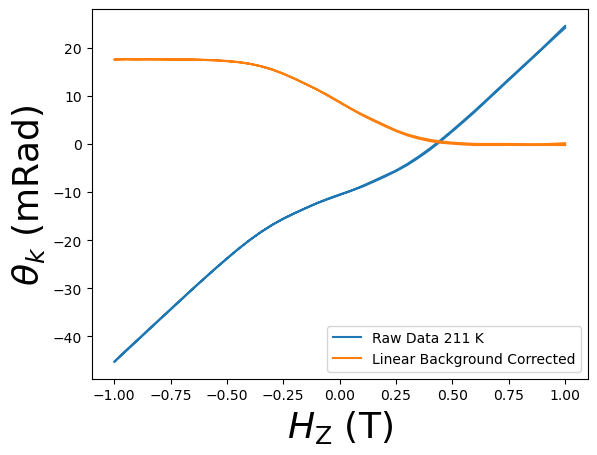

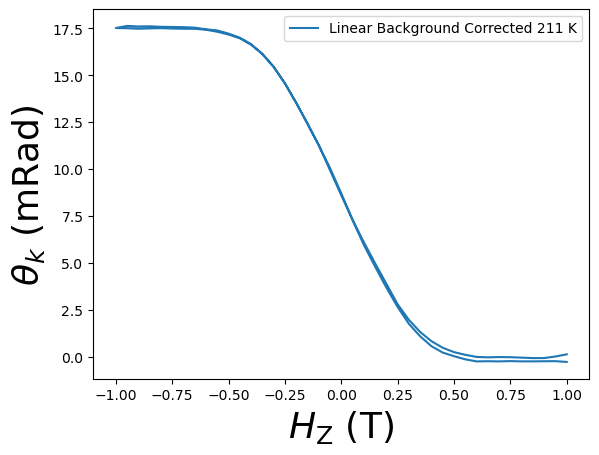

In [45]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_211K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:10], OOP1.ThetaK[:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 211 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 211 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_52236\25867492.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


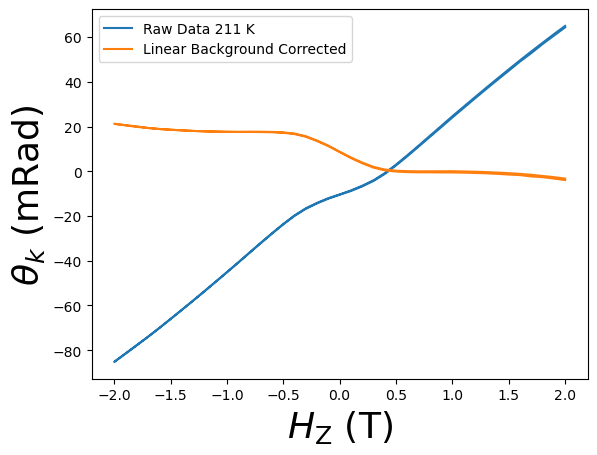

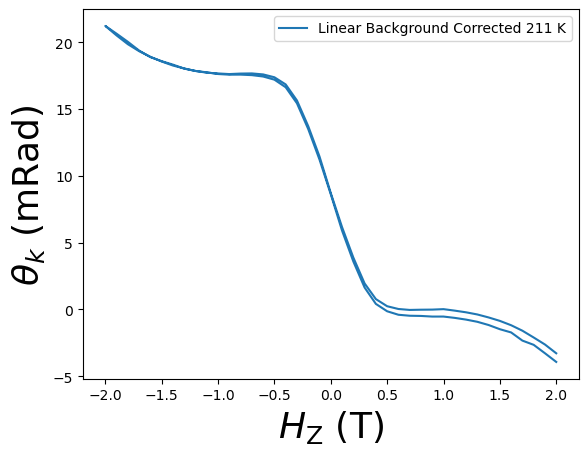

In [47]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_211K_2T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[10:15], OOP1.ThetaK[10:15])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 211 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 211 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\1589603536.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\1589603536.py:5: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaK_shifted = OOP1.ThetaK - OOP1_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\1589603536.py:7: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg_shifted = OOP1.ThetaKavg - OOP1_avg_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\1589603536.py:11: UserWarning: Pandas doesn't allow columns to be crea

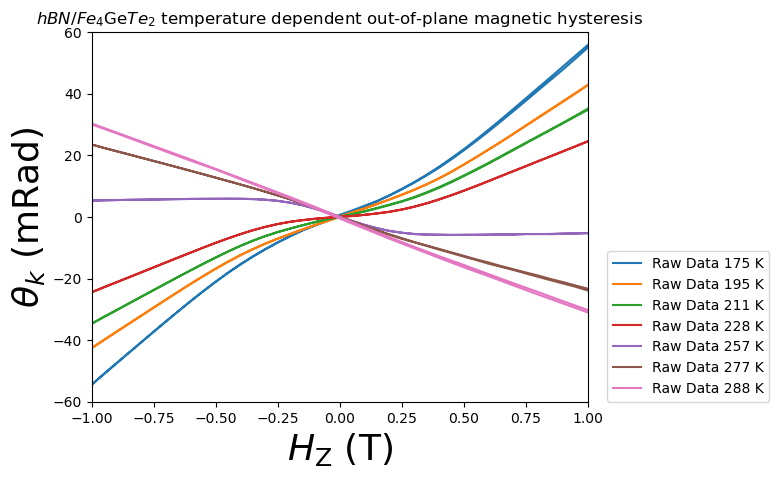

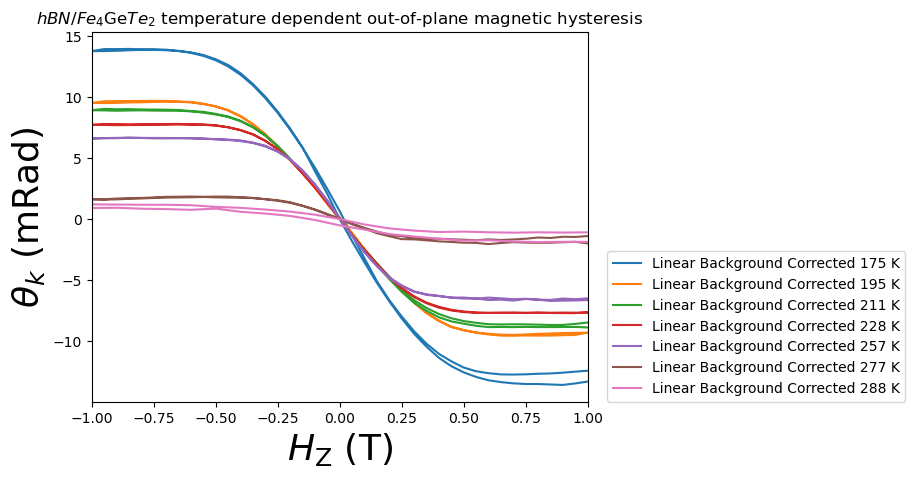

In [5]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_211K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[0:10], OOP1.ThetaK[0:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
OOP1_shift = OOP1.ThetaK[OOP1.sweep_field == 0].values[0]
OOP1.ThetaK_shifted = OOP1.ThetaK - OOP1_shift
OOP1_avg_shift = OOP1.ThetaKavg[OOP1.sweep_field == 0].values[0]
OOP1.ThetaKavg_shifted = OOP1.ThetaKavg - OOP1_avg_shift
                   
OOP2 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_1 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv',comment='#')
popt2, pcov2 = curve_fit(lin,OOP2.sweep_field[:10], OOP2.ThetaK[:10])
OOP2.ThetaKavg = OOP2.ThetaK - (OOP2.sweep_field*popt2[0] + popt2[1])
OOP2_shift = OOP2.ThetaK[OOP2.sweep_field == 0].values[0]
OOP2.ThetaK_shifted = OOP2.ThetaK - OOP2_shift
OOP2_avg_shift = OOP2.ThetaKavg[OOP2.sweep_field == 0].values[0]
OOP2.ThetaKavg_shifted = OOP2.ThetaKavg - OOP2_avg_shift

OOP3 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-04\RTOOP_107.017_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-04_1.csv',comment='#')
popt3, pcov3 = curve_fit(lin,OOP3.sweep_field[30:35], OOP3.ThetaK[30:35])
OOP3.ThetaKavg = OOP3.ThetaK - (OOP3.sweep_field*popt3[0] + popt3[1])
OOP3_shift = OOP3.ThetaK[OOP3.sweep_field == 0].values[0]
OOP3.ThetaK_shifted = OOP3.ThetaK - OOP3_shift
OOP3_avg_shift = OOP3.ThetaKavg[OOP3.sweep_field == 0].values[0]
OOP3.ThetaKavg_shifted = OOP3.ThetaKavg - OOP3_avg_shift

OOP4 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_195K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_2.csv',comment='#')
popt4, pcov4 = curve_fit(lin,OOP4.sweep_field[:10], OOP4.ThetaK[:10])
OOP4.ThetaKavg = OOP4.ThetaK - (OOP4.sweep_field*popt4[0] + popt4[1])
OOP4_shift = OOP4.ThetaK[OOP4.sweep_field == 0].values[0]
OOP4.ThetaK_shifted = OOP4.ThetaK - OOP4_shift
OOP4_avg_shift = OOP4.ThetaKavg[OOP4.sweep_field == 0].values[0]
OOP4.ThetaKavg_shifted = OOP4.ThetaKavg - OOP4_avg_shift

OOP5 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-09\OOP_107.017_tc1s_175K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-09_1.csv',comment='#')
popt5, pcov5 = curve_fit(lin,OOP5.sweep_field[:8], OOP5.ThetaK[:8])
OOP5.ThetaKavg = OOP5.ThetaK - (OOP5.sweep_field*popt5[0] + popt5[1])
OOP5_shift = OOP5.ThetaK[OOP5.sweep_field == 0].values[0]
OOP5.ThetaK_shifted = OOP5.ThetaK - OOP5_shift
OOP5_avg_shift = OOP5.ThetaKavg[OOP5.sweep_field == 0].values[0]
OOP5.ThetaKavg_shifted = OOP5.ThetaKavg - OOP5_avg_shift

OOP6 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-10\OOP_107.017_tc1s_257K_1T_hBNFGT_SagnacHeterodyne_V1.0000V_A0.0_step0_x0_y0_2024-10-10_4.csv',comment='#')
popt6, pcov6 = curve_fit(lin,OOP6.sweep_field[:8], OOP6.ThetaK[:8])
OOP6.ThetaKavg = OOP6.ThetaK - (OOP6.sweep_field*popt6[0] + popt6[1])
OOP6_shift = OOP6.ThetaK[OOP6.sweep_field == 0].values[0]
OOP6.ThetaK_shifted = OOP6.ThetaK - OOP6_shift
OOP6_avg_shift = OOP6.ThetaKavg[OOP6.sweep_field == 0].values[0]
OOP6.ThetaKavg_shifted = OOP6.ThetaKavg - OOP6_avg_shift

OOP7 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-11\OOP_107.017_tc1s_277K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-11_1.csv',comment='#')
popt7, pcov7 = curve_fit(lin,OOP7.sweep_field[:8], OOP7.ThetaK[:8])
OOP7.ThetaKavg = OOP7.ThetaK - (OOP7.sweep_field*popt7[0] + popt7[1])
OOP7_shift = OOP7.ThetaK[OOP7.sweep_field == 0].values[0]
OOP7.ThetaK_shifted = OOP7.ThetaK - OOP7_shift
OOP7_avg_shift = OOP7.ThetaKavg[OOP7.sweep_field == 0].values[0]
OOP7.ThetaKavg_shifted = OOP7.ThetaKavg - OOP7_avg_shift


plt.figure(dpi=100)
plt.xlim(-1, 1)
plt.ylim(-60,60)
plt.title('$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis')
plt.plot(OOP5.sweep_field,OOP5.ThetaK_shifted*1e3, label = 'Raw Data 175 K')
plt.plot(OOP4.sweep_field,OOP4.ThetaK_shifted*1e3, label = 'Raw Data 195 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaK_shifted*1e3, label = 'Raw Data 211 K')
plt.plot(OOP2.sweep_field,OOP2.ThetaK_shifted*1e3, label = 'Raw Data 228 K')
plt.plot(OOP6.sweep_field,OOP6.ThetaK_shifted*1e3, label = 'Raw Data 257 K')
plt.plot(OOP7.sweep_field,OOP7.ThetaK_shifted*1e3, label = 'Raw Data 277 K')
plt.plot(OOP3.sweep_field,OOP3.ThetaK_shifted*1e3, label = 'Raw Data 288 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend(loc=(1.04, 0))


plt.figure(dpi=100)
plt.xlim(-1, 1)
plt.title('$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis')
plt.plot(OOP5.sweep_field,OOP5.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 175 K')
plt.plot(OOP4.sweep_field,OOP4.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 195 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 211 K')
plt.plot(OOP2.sweep_field,OOP2.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 228 K')
plt.plot(OOP6.sweep_field,OOP6.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 257 K')
plt.plot(OOP7.sweep_field,OOP7.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 277 K')
plt.plot(OOP3.sweep_field,OOP3.ThetaKavg_shifted*1e3,label = 'Linear Background Corrected 288 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend(loc=(1.04, 0))


C:\Users\luogroup\AppData\Local\Temp\ipykernel_52236\4215845934.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


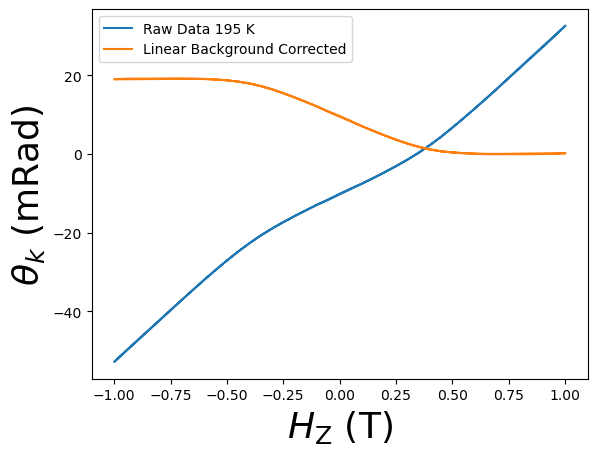

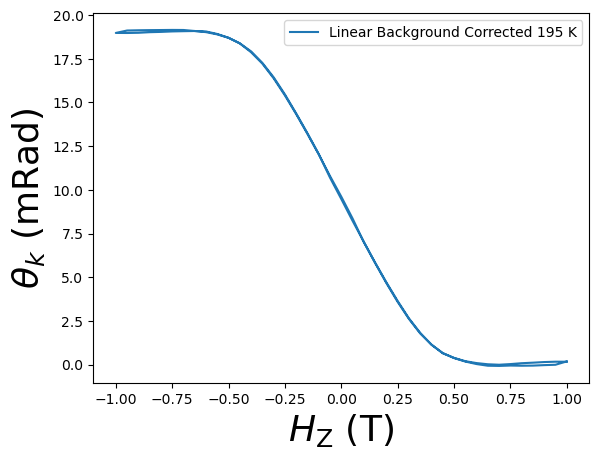

In [163]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_195K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_2.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:10], OOP1.ThetaK[:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 195 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 195 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_52236\731755557.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


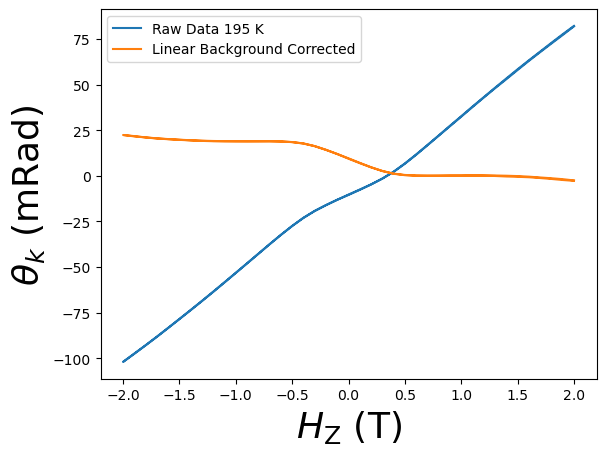

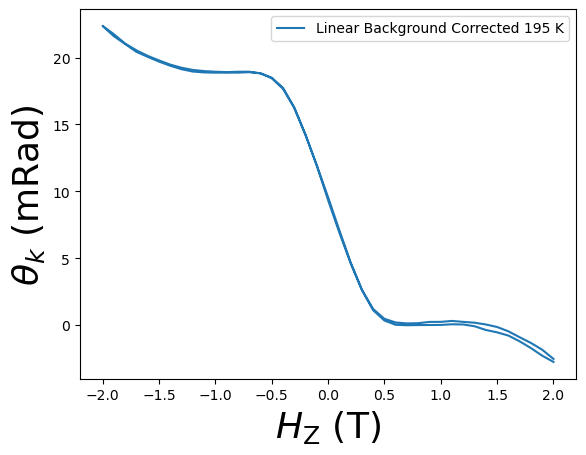

In [170]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_195K_2T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[10:15], OOP1.ThetaK[10:15])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 195 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 195 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_52236\3729223217.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


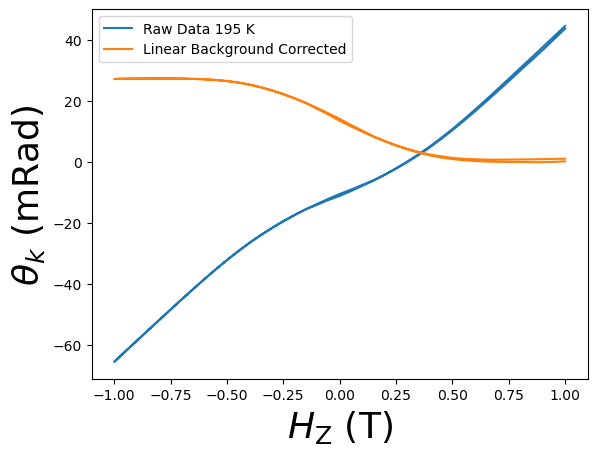

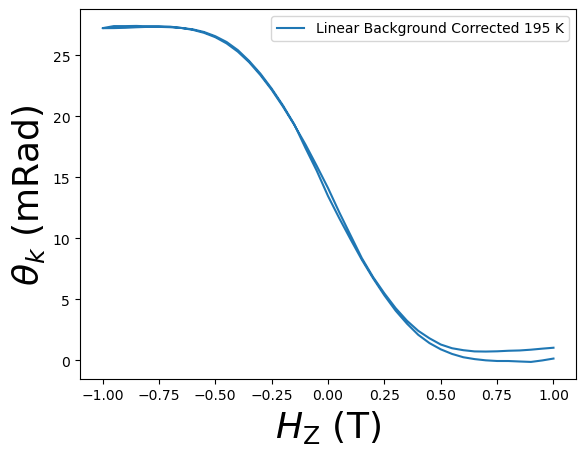

In [184]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-09\OOP_107.017_tc1s_175K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-09_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:8], OOP1.ThetaK[:8])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 195 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 195 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\4085108177.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


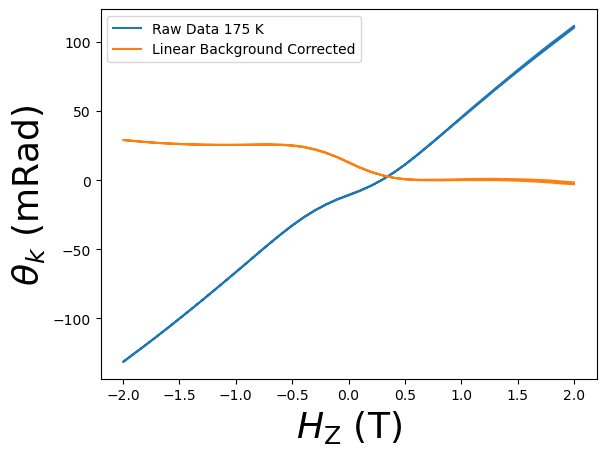

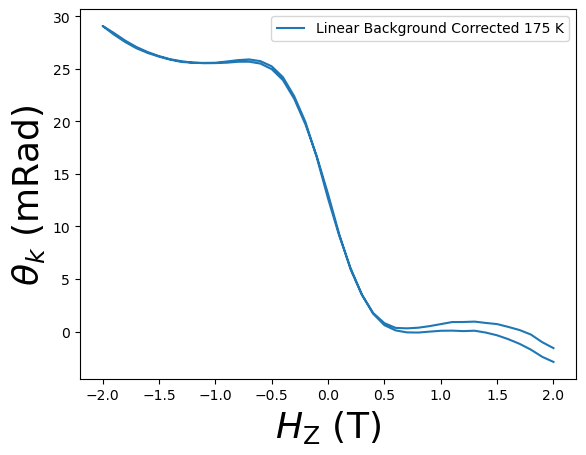

In [13]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-09\OOP_107.017_tc1s_175K_2T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-09_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[10:15], OOP1.ThetaK[10:15])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 175 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 175 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\2979833363.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


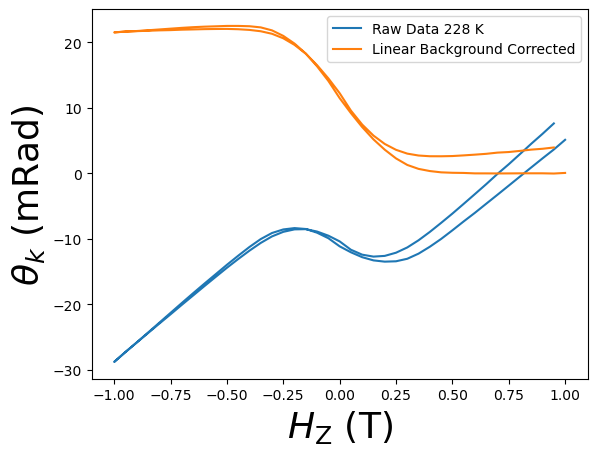

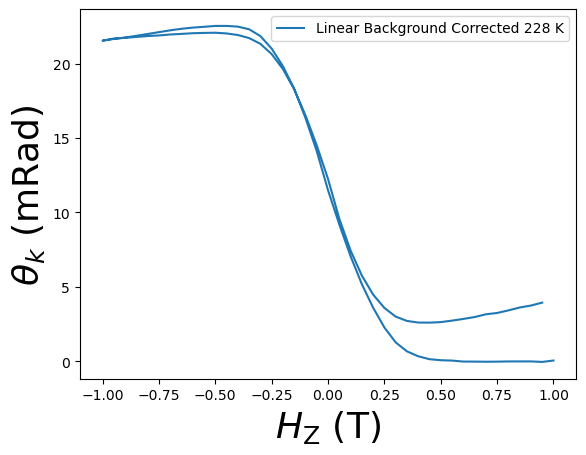

In [15]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-10\OOP_107.017_tc1s_228K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-10_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:10], OOP1.ThetaK[:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 228 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 228 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_8996\1248990536.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


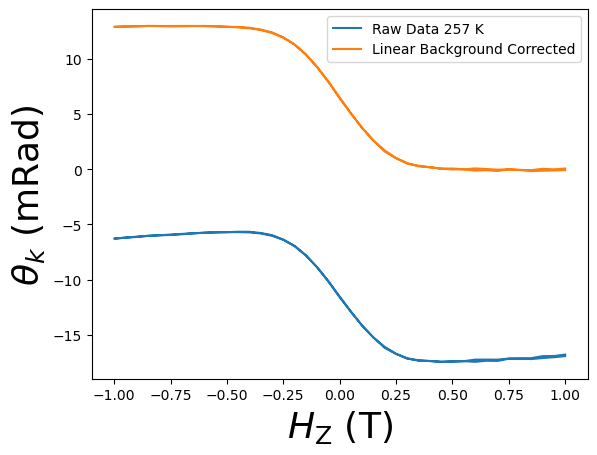

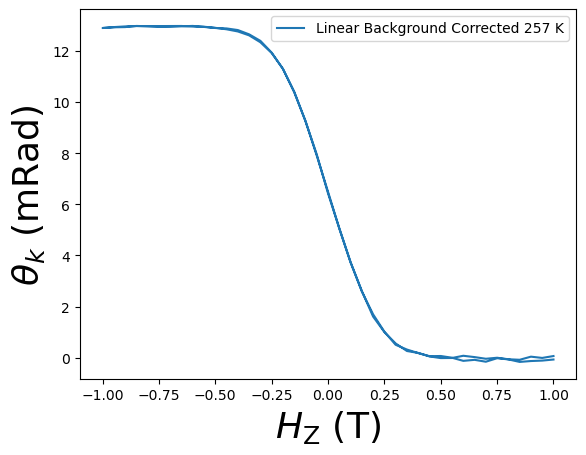

In [16]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-10\OOP_107.017_tc1s_257K_1T_hBNFGT_SagnacHeterodyne_V1.0000V_A0.0_step0_x0_y0_2024-10-10_4.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:10], OOP1.ThetaK[:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 257 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 257 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\3778441885.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])


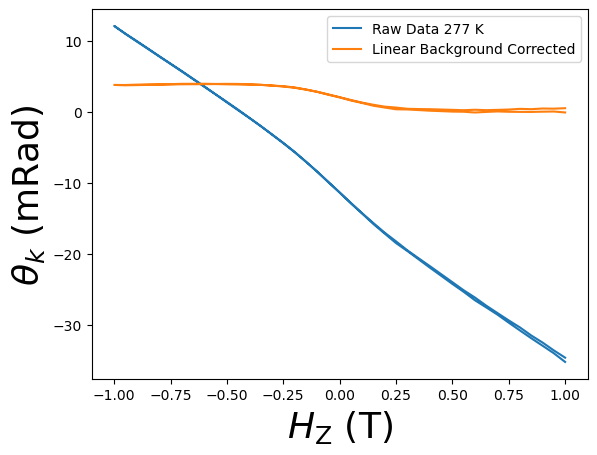

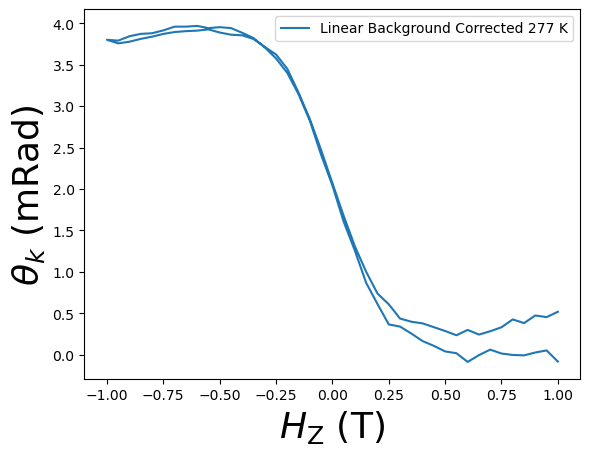

In [3]:
OOP1 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-11\OOP_107.017_tc1s_277K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-11_1.csv',comment='#')
popt, pcov = curve_fit(lin,OOP1.sweep_field[:10], OOP1.ThetaK[:10])
OOP1.ThetaKavg = OOP1.ThetaK - (OOP1.sweep_field*popt[0] + popt[1])
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaK*1e3, label = 'Raw Data 277 K')
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()
plt.figure(dpi=100)
plt.plot(OOP1.sweep_field,OOP1.ThetaKavg*1e3,label = 'Linear Background Corrected 277 K')
#plt.title('Raw Data')
plt.ylabel('$\\theta_k$ (mRad)',fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)',fontsize=26)
plt.legend()

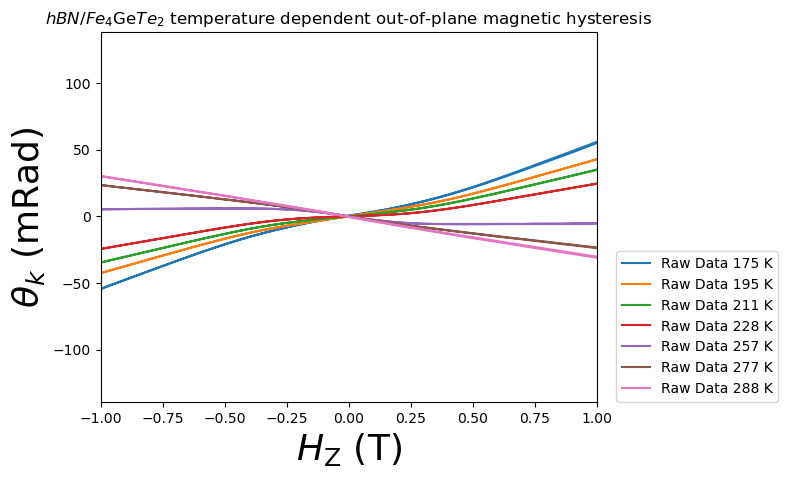

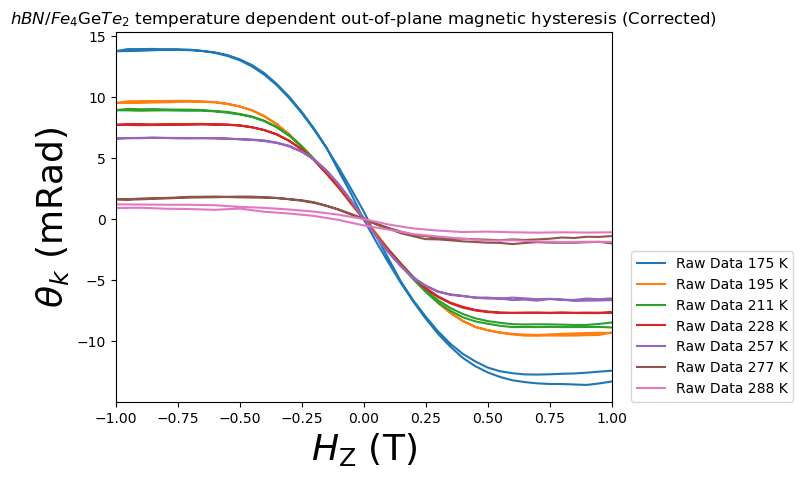

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def lin(x, a, b):
    return a * x + b

def process_data(file_path, sweep_field_range):
    # Load the data
    data = pd.read_csv(file_path, comment='#')
    
    # Use the provided range for curve fitting
    start, end = sweep_field_range
    
    # Fit a linear curve to the sweep_field and ThetaK within the provided range
    popt, _ = curve_fit(lin, data.sweep_field[start:end], data.ThetaK[start:end])
    
    # Perform background correction
    data['ThetaKavg'] = data.ThetaK - (data.sweep_field * popt[0] + popt[1])
    
    # Find the shift at 0 field
    ThetaK_shift = data.ThetaK[data.sweep_field == 0].values[0]
    ThetaKavg_shift = data.ThetaKavg[data.sweep_field == 0].values[0]
    
    # Apply the shift
    data['ThetaK_shifted'] = data.ThetaK - ThetaK_shift
    data['ThetaKavg_shifted'] = data.ThetaKavg - ThetaKavg_shift
    
    return data

def plot_data(data_list, labels, title, y_label, corrected=False):
    plt.figure(dpi=100)
    plt.xlim(-1, 1)
    plt.title(title)
    
    for data, label in zip(data_list, labels):
        if corrected:
            plt.plot(data.sweep_field, data.ThetaKavg_shifted * 1e3, label=label)
        else:
            plt.plot(data.sweep_field, data.ThetaK_shifted * 1e3, label=label)
    
    plt.ylabel(y_label, fontsize=26)
    plt.xlabel('$H_{\\rm{Z}}$ (T)', fontsize=26)
    plt.legend(loc=(1.04, 0))

# Define your file paths
file_paths = [
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-09\OOP_107.017_tc1s_175K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-09_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_195K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_2.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_211K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_1 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-10\OOP_107.017_tc1s_257K_1T_hBNFGT_SagnacHeterodyne_V1.0000V_A0.0_step0_x0_y0_2024-10-10_4.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-11\OOP_107.017_tc1s_277K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-11_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-04\RTOOP_107.017_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-04_1.csv'
]

# Define the sweep field ranges for curve fitting for each dataset
sweep_field_ranges = [
    (0, 8),  # Range for 175K
    (0, 10),  # Range for 195K
    (0, 10),  # Range for 211K
    (0, 10),  # Range for 228K
    (0, 8),  # Range for 257K
    (0, 8),   # Range for 277K
    (30, 35)  # Range for RT 288K
]

# Process each file with the corresponding sweep field range
processed_data = [process_data(fp, rng) for fp, rng in zip(file_paths, sweep_field_ranges)]

# Define labels for each dataset (matching the file paths)
labels = [
    'Raw Data 175 K', 'Raw Data 195 K', 'Raw Data 211 K',
    'Raw Data 228 K', 'Raw Data 257 K', 'Raw Data 277 K', 'Raw Data 288 K'
]

# Plot the raw data
plot_data(processed_data, labels, '$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis', '$\\theta_k$ (mRad)', corrected=False)

# Plot the background-corrected data
plot_data(processed_data, labels, '$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis (Corrected)', '$\\theta_k$ (mRad)', corrected=True)

plt.show()


C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\301729107.py:9: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP3.ThetaKavg = OOP3.ThetaK - (OOP3.sweep_field*popt3[0] + popt3[1])
C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\301729107.py:11: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP3.ThetaK_shifted = OOP3.ThetaK - OOP3_shift
C:\Users\luogroup\AppData\Local\Temp\ipykernel_18832\301729107.py:13: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  OOP3.ThetaKavg_shifted = OOP3.ThetaKavg - OOP3_avg_shift


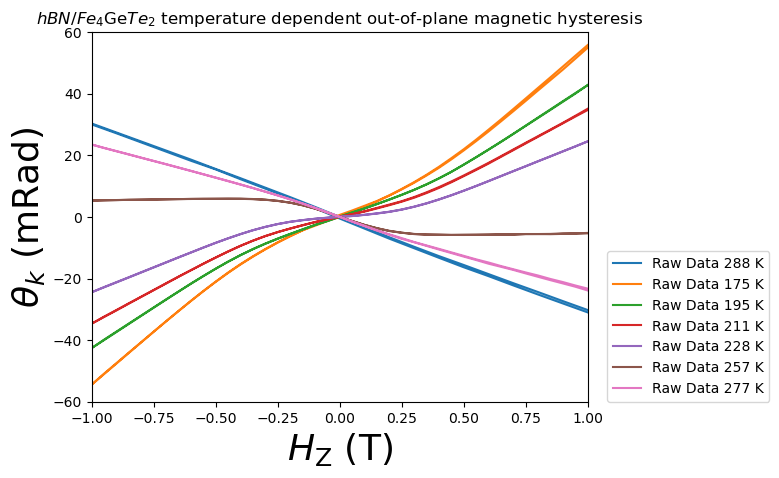

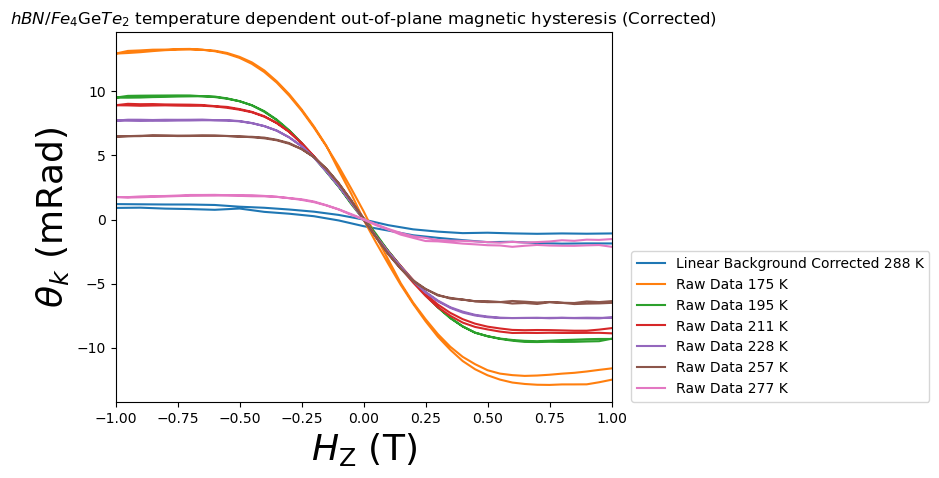

In [37]:
# Automated
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

OOP3 = pd.read_csv(r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-04\RTOOP_107.017_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-04_1.csv',comment='#')
popt3, pcov3 = curve_fit(lin,OOP3.sweep_field[30:35], OOP3.ThetaK[30:35])
OOP3.ThetaKavg = OOP3.ThetaK - (OOP3.sweep_field*popt3[0] + popt3[1])
OOP3_shift = OOP3.ThetaK[OOP3.sweep_field == 0].values[0]
OOP3.ThetaK_shifted = OOP3.ThetaK - OOP3_shift
OOP3_avg_shift = OOP3.ThetaKavg[OOP3.sweep_field == 0].values[0]
OOP3.ThetaKavg_shifted = OOP3.ThetaKavg - OOP3_avg_shift

def lin(x, a, b):
    return a * x + b

def process_data(file_path, sweep_field_range=None):
    # Load the data
    data = pd.read_csv(file_path, comment='#')
    
    # Fit a linear curve to the initial part of the sweep_field and ThetaK
    if sweep_field_range is not None:
        start, end = sweep_field_range
    else:
        start, end = 0, 10  # Default range
    
    popt, _ = curve_fit(lin, data.sweep_field[start:end], data.ThetaK[start:end])
    
    # Perform background correction
    data['ThetaKavg'] = data.ThetaK - (data.sweep_field * popt[0] + popt[1])
    
    # Find the shift at 0 field
    ThetaK_shift = data.ThetaK[data.sweep_field == 0].values[0]
    ThetaKavg_shift = data.ThetaKavg[data.sweep_field == 0].values[0]
    
    # Apply the shift
    data['ThetaK_shifted'] = data.ThetaK - ThetaK_shift
    data['ThetaKavg_shifted'] = data.ThetaKavg - ThetaKavg_shift
    
    return data

def plot_data(data_list, labels, title, y_label, corrected=False):
    plt.figure(dpi=100)
    plt.xlim(-1, 1)
    plt.title(title)
    
    for data, label in zip(data_list, labels):
        if corrected:
            plt.plot(data.sweep_field, data.ThetaKavg_shifted * 1e3, label=label)
        else:
            plt.plot(data.sweep_field, data.ThetaK_shifted * 1e3, label=label)
    
    plt.ylabel(y_label, fontsize=26)
    plt.xlabel('$H_{\\rm{Z}}$ (T)', fontsize=26)
    plt.legend(loc=(1.04, 0))

# Define your file paths
file_paths = [
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-09\OOP_107.017_tc1s_175K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-09_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_195K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_2.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-08\OOP_107.017_tc1s_211K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-08_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-06\RTOOP_107.017_tc1s_228K_1 T_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-06_1.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-10\OOP_107.017_tc1s_257K_1T_hBNFGT_SagnacHeterodyne_V1.0000V_A0.0_step0_x0_y0_2024-10-10_4.csv',
    r'C:\Users\luogroup\Documents\Sagnac Data\HighZF4GThBN\2024-10-11\OOP_107.017_tc1s_277K_1T_hBNFGT_SagnacHeterodyne_V0.0000V_A0.0_step0_x0_y0_2024-10-11_1.csv'
]

# Process each file
processed_data = [process_data(fp) for fp in file_paths]

# Define labels for each dataset (matching the file paths)
labels = [
    'Raw Data 175 K', 'Raw Data 195 K', 'Raw Data 211 K',
    'Raw Data 228 K', 'Raw Data 257 K', 'Raw Data 277 K'
]

# First plot: Raw data (including OOP3 and the rest of the datasets)
plt.figure(dpi=100)
plt.xlim(-1, 1)
plt.ylim(-60, 60)
plt.plot(OOP3.sweep_field, OOP3.ThetaK_shifted * 1e3, label='Raw Data 288 K')

# Loop through the processed data and plot each one with corresponding label
for data, label in zip(processed_data, labels):
    plt.plot(data.sweep_field, data.ThetaK_shifted * 1e3, label=label)

plt.ylabel('$\\theta_k$ (mRad)', fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)', fontsize=26)
plt.legend(loc=(1.04, 0))
plt.title('$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis')
plt.show()

# Second plot: Corrected data (including OOP3 and the rest of the datasets)
plt.figure(dpi=100)
plt.xlim(-1, 1)
plt.plot(OOP3.sweep_field, OOP3.ThetaKavg_shifted * 1e3, label='Linear Background Corrected 288 K')

# Loop through the processed data and plot the corrected data with corresponding label
for data, label in zip(processed_data, labels):
    plt.plot(data.sweep_field, data.ThetaKavg_shifted * 1e3, label=label)

plt.ylabel('$\\theta_k$ (mRad)', fontsize=26)
plt.xlabel('$H_{\\rm{Z}}$ (T)', fontsize=26)
plt.legend(loc=(1.04, 0))
plt.title('$hBN/Fe_{\\rm{4}}$Ge$Te_{\\rm{2}}$ temperature dependent out-of-plane magnetic hysteresis (Corrected)')
plt.show()

